# 13강 One-Class Classification

**참고 문헌:**
- Tax, D. M., & Duin, R. P. (2004). Support vector data description. *Machine learning, 54*, 45-66.

https://link.springer.com/article/10.1023/B:MACH.0000008084.60811.49

- Schölkopf, B., Platt, J. C., Shawe-Taylor, J., Smola, A. J., & Williamson, R. C. (2001). Estimating the support of a high-dimensional distribution. *Neural computation, 13(7)*, 1443-1471.

https://www.microsoft.com/en-us/research/wp-content/uploads/2016/02/tr-99-87.pdf

13강에서는 **One-Class**(단일 클래스) 문제를 어떻게 다루는지, 특히, **Support Vector Data Description**과 **One-Class $\nu$-SVM** 기법을 중심으로 설명한다.  
일반적인 밀도 추정(density estimation) 대신 **에센셜 서포트**(essential support)를 찾고, 이를 통해 **이상치**(anomaly) 혹은 **비정상 영역**을 판별하는 방법을 살펴본다.

## 1. One-Class Problem이란?

### 1.1 정의 및 목표

- **Goal**: 한 클래스(정상이라 가정)를 다른 모든 객체(비정상)로부터 구분하고 싶음  
- **Training 데이터**: 정상 클래스에 대한 샘플 $\{\mathbf{x}_i\}_{i=1}^N$만이 주어짐  
  - 비정상 클래스(Outlier) 샘플은 거의 없거나 전혀 없다고 가정  
- **아이디어**: 주어진 데이터가 형성하는 **주요 지지(support)** 영역을 찾아서, 그 영역 밖의 샘플을 “비정상”으로 판정

### 1.2 전통적 접근

- 예: **밀도 기반** 접근 → 밀도가 충분히 높은 영역을 “정상”으로 보고, 밀도가 낮은 지점은 “이상치”로 간주  
  - 문제: 밀도 추정은 고차원에서 매우 어려움(차원의 저주)  
  - 또 다른 아이디어: **단순 경계 설정**(threshold)으로 “정상” 영역을 구체적으로 둘러싸는 방법을 모색

## 2. SVDD (Support Vector Data Description)

### 2.1 개념

SVDD는 **서포트 벡터** 머신의 아이디어를 활용하여, **한 클래스**를 감싸는 **최소 구(球)**(혹은 더 일반적으로 최소 볼륨의 형태)로 정의한다.

1. **목표**: 입력 데이터 $\{\mathbf{x}_i \in \mathbb{R}^d \}$를 모두 포함(혹은 대부분 포함)하는 **반지름** $R$을 최소화하는 구를 찾는다.  
   - 중심: $\mathbf{a} \in \mathbb{R}^d $  
   - 반지름: $R$  (스칼라)
2. 이후 어떤 새로운 점 $\mathbf{x}$가 이 구 밖에 있으면 (즉, $\|\mathbf{x} - \mathbf{a}\| > R$ ) 비정상(outlier)으로 본다.

### 2.2 기본 수식

$$
\begin{aligned}
 \min_{R^2, \;\mathbf{a}}& \quad R^2 \\
 \text{subject to}& \quad \|\mathbf{x}_i - \mathbf{a}\|^2 \le R^2, \quad  i = 1, \cdots, N.
\end{aligned}
$$
- 즉, $\|\mathbf{x}_i - \mathbf{a}\|$가 $R$ 이하가 되도록 하는 **최소** $R$

   $\big($커널화 시 $\| \boldsymbol{\phi}(\mathbf{x}_i) - \boldsymbol{\phi}(\mathbf{a})\|\le R$ $\big)$

#### 라그랑지안 및 듀얼 문제로 확장

위 문제는 **라그랑주 승수** $\alpha_i$를 도입해 최적화할 수 있으며, 커널 트릭(고차원 매핑)도 가능해져서 **비선형** 경계까지 확장 가능.

## 3. Hard SVDD 


### 3.1 결정 함수 (Decision Function)
$$
f(\mathbf{x})=\|\mathbf{x}-\mathbf{a}\|^2-R^2
$$
- $\mathbf{a}$: 구의 중심. 
- $R$: 구의 반지름.
- $f(\mathbf{x}) \le 0 $ : $\mathbf{x}$가 구의 경계 안에 있거나 경계 위에 있음 -> **정상(normal)**
- $f(\mathbf{x}) > 0 $ : $\mathbf{x}$가 구의 경계 밖에 있음 -> **이상치(outlier)**

### 3.2 Primal Formulation

$$
\begin{aligned}
 \min_{R^2, \; \mathbf{a}}& \quad R^2 \\
 \text{subject to}& \quad \|\mathbf{x}_i - \mathbf{a}\|^2 \le R^2, \quad  i = 1, \cdots, N.
\end{aligned}
$$

### 3.3 Lagrangian

라그랑주 승수 $\alpha_i \ge 0$를 붙여서 듀얼 문제를 정리하면:

$$
\begin{aligned}
\mathcal{L}(R^2, \mathbf{a}, \boldsymbol{\alpha}) &=
R^2 + \sum_{i=1}^N  \alpha_i \left(\|\mathbf{x}_i - \mathbf{a}\|^2 - R^2 \right) \\
&=
R^2 \left(1 - \sum_{i=1}^N  \alpha_i \right)+ \sum_{i=1}^N \alpha_i \|\mathbf{x}_i - \mathbf{a}\|^2 .
\end{aligned}
$$

### 3.4 Stationarity 조건

(1) $\dfrac{\partial \mathcal{L}}{\partial R^2} = 0$ 

$$
\sum_{i=1}^N \alpha_i = 1
$$


(2) $\dfrac{\partial \mathcal{L}}{\partial \mathbf{a}} = 0$

$$
\begin{aligned}
& \sum_{i=1}^N \alpha_i \|\mathbf{x}_i - \mathbf{a}\|^2 \\
= & \sum_{i=1}^N \alpha_i (\mathbf{x}_i - \mathbf{a})^T  (\mathbf{x}_i - \mathbf{a})\\
= & \sum_{i=1}^N \alpha_i (\mathbf{x}_i^T \mathbf{x}_i - 2 \mathbf{a} \mathbf{x}_i + \mathbf{a}^T \mathbf{a}) .
\end{aligned}
$$

<br>

$$
\dfrac{\partial}{\partial \mathbf{a}} \sum_{i=1}^N \alpha_i (\mathbf{x}_i^T \mathbf{x}_i - 2 \mathbf{a} \mathbf{x}_i + \mathbf{a}^T \mathbf{a})  = \sum_{i=1}^N \alpha_i (-2 \mathbf{x}_i + 2 \mathbf{a}) = \mathbf{0}
$$

<br>

$$
\sum_{i=1}^N \alpha_i \mathbf{x}_i =   \mathbf{a} \times \sum_{i=1}^N \alpha_i
$$

위의 식 (1)에서, $\sum_{i=1}^N \alpha_i = 1$ 이므로,
$$
\mathbf{a} =
\sum_{i=1}^N \alpha_i \, \mathbf{x}_i .
$$

### 3.5 Dual 최적화

$$
\begin{align}
\mathcal{L}(R^{2*}, \mathbf{a}^*, \boldsymbol{\alpha}) &= \sum_{i=1}^N \alpha_i \left( \mathbf{x}_i - \mathbf{a}^* \right)^T \left(\mathbf{x}_i - \mathbf{a}^* \right)  \\
&= \sum_{i=1}^N \alpha_i ( \mathbf{x}_i \cdot \mathbf{x}_i ) - 2 \sum_{i=1}^N \alpha_i (\mathbf{x}_i \cdot \mathbf{a}^* ) + \sum_{i=1}^N \alpha_i (\mathbf{a}^* \cdot \mathbf{a}^* ) \\
&= \sum_{i=1}^N \alpha_i ( \mathbf{x}_i \cdot \mathbf{x}_i ) - 2 \sum_{i=1}^N \alpha_i \left(   \mathbf{x}_i \cdot \sum_{j=1}^N \alpha_j \, \mathbf{x}_j\right) + \sum_{i=1}^N \alpha_i \left(\sum_{j=1}^N \alpha_j \, \mathbf{x}_j \cdot \sum_{k=1}^N \alpha_k \, \mathbf{x}_k \right) \\
&= \sum_{i=1}^N \alpha_i ( \mathbf{x}_i \cdot \mathbf{x}_i ) - 2 \sum_{i=1}^N  \sum_{j=1}^N \alpha_i \alpha_j ( \mathbf{x}_i \cdot \mathbf{x}_j )  +  \sum_{i=1}^N \alpha_i \, \mathbf{x}_i \cdot \sum_{j=1}^N \alpha_j \, \mathbf{x}_j \\
&= \sum_{i=1}^N \alpha_i ( \mathbf{x}_i \cdot \mathbf{x}_i ) - \sum_{i=1}^N  \sum_{j=1}^N \alpha_i \alpha_j ( \mathbf{x}_i \cdot \mathbf{x}_j )  .
\end{align}
$$
<br>
$$
\begin{align}
\max_{\boldsymbol{\alpha}}\quad &
  \sum_{i=1}^N \alpha_i (\mathbf{x}_i \cdot \mathbf{x}_i) - \sum_{i=1}^N \sum_{j=1}^N \alpha_i \alpha_j \,(\mathbf{x}_i \cdot \mathbf{x}_j) \\
\text{subject to}\quad& \sum_{i=1}^N \alpha_i = 1,\quad  \alpha_i \ge 0 , \quad i=1,\cdots,N.
\end{align}
$$

## 4. Soft SVDD
Soft SVDD는 Hard SVDD의 이론적 기초 위에, **슬랙 변수**와 **패널티 계수** $C$를 도입하여 실제 데이터의 노이즈나 이상치를 일정 부분 허용할 수 있게 만든다. 
- 실제로 모든 점을 구 안에 완벽히 포함하기 어렵거나 오버피팅이 우려될 수 있으므로, **슬랙 변수** $\xi_i \ge 0$ 도입  
- 제약: $\|\mathbf{x}_i - \mathbf{a}\|^2 \le R^2 + \xi_i$  
- 목적함수: $\min R^2 + C \sum_i \xi_i$  
- 듀얼 문제에서는 $0 \le \alpha_i \le C$ 제약이 들어감 (C-SVM과 유사).
- 최적해 $\alpha_i$로부터 중심 $\mathbf{a}$와 반지름 $R$을 구하고, **이상치(Outlier)** 혹은 경계에서 벗어난 점들에 대해서는 $\xi_i$가 양수가 되어 패널티를 부과한다.

### 4.1 Mathematical Formulation of Soft SVDD 

**Soft SVDD**의 Primal 및 Dual 문제를 살펴보고 **KKT 조건**을 간략히 유도해보자.

Hard SVDD에서는 모든 데이터 점이 구(ball) 안에 포함되어야 하지만, 현실적으로 모든 점을 엄격히 포함하기 어려운 경우가 많다. 이를 보완하기 위해 **슬랙 변수** $\xi_i \ge 0$를 도입하여 일부 점이 구의 경계를 벗어날 수 있도록 허용하고, 그만큼의 패널티를 목적으로 추가한다.

### 4.2 Primal 문제 

$$
\begin{aligned}
\min_{R^2, \;\mathbf{a},\; \boldsymbol{\xi}} \quad & R^2 \;+\; C \sum_{i=1}^N \xi_i \\
\text{subject to} \quad
& \|\mathbf{x}_i - \mathbf{a}\|^2 \;\le\; R^2 + \xi_i, \quad  i=1,\dots,N, \\
& \xi_i \;\ge\; 0, \quad i=1,\dots,N.
\end{aligned}
$$

- $R \ge 0$: 구의 반지름
- $\mathbf{a} \in \mathbb{R}^d$: 구의 중심
- $\xi_i \ge 0$: 슬랙 변수 (i번째 점이 경계를 벗어난 정도)
- $C > 0$: 슬랙 변수에 대한 패널티를 조절하는 하이퍼파라미터

$\displaystyle R^2$을 최소화하려고 하되, 각 슬랙 변수 $\xi_i$에 대해서는 $\displaystyle C \sum_i \xi_i$만큼의 추가 비용을 부과한다. $C$가 클수록 슬랙을 허용하지 않고 구 안에 최대한 가두려 하고, $C$가 작으면 일부 점이 구 밖으로 나가더라도 벌칙을 크게 주지 않는다.

### 4.3 Lagrangian (듀얼 문제) 도출

Primal 문제의 제약식을 반영하기 위해 **라그랑주 승수** 도입:

- $\alpha_i \ge 0$ : $\|\mathbf{x}_i - \mathbf{a}\|^2 \le R^2 + \xi_i$ 제약에 대한 승수
- $\gamma_i \ge 0$ : $\xi_i \ge 0$ 제약에 대한 승수

**Lagrangian 정의**

$$
\mathcal{L}\bigl(R^2, \mathbf{a}, \boldsymbol{\xi}, \boldsymbol{\alpha}, \boldsymbol{\gamma}\bigr)
=
R^2
\;+\;
C \sum_{i=1}^N \xi_i
\;-\;
\sum_{i=1}^N \alpha_i \Bigl(R^2 + \xi_i - \|\mathbf{x}_i - \mathbf{a}\|^2\Bigr)
\;-\;
\sum_{i=1}^N \gamma_i \,\xi_i.
$$

이를 항별로 정리하면:

1. **목적항**: $R^2 + C\sum_i \xi_i$
2. **제약항**:  
   - $\alpha_i \ge 0$가 곱해진 $-\bigl(R^2 + \xi_i - \|\mathbf{x}_i - \mathbf{a}\|^2\bigr) \le 0$  
   - $\gamma_i \ge 0$가 곱해진 $-\xi_i \le 0$

### 4.4 KKT 조건

라그랑지안을 미분하여 Stationarity 조건을 살펴보자.

(1) **$\displaystyle \frac{\partial \mathcal{L}}{\partial R^2} = 0$**  
   $$
   1 - \sum_{i=1}^N \alpha_i = 0
   \quad \implies \quad
   \sum_{i=1}^N \alpha_i = 1.
   $$
<br>
(2) $\displaystyle \frac{\partial \mathcal{L}}{\partial \mathbf{a}} = 0$

   $$
   \frac{\partial}{\partial \mathbf{a}} \Bigl(-\sum_i \alpha_i \cdot \bigl(- \|\mathbf{x}_i - \mathbf{a}\|^2\bigr)\Bigr)   =
   \frac{\partial}{\partial \mathbf{a}} \Bigl(\sum_i \alpha_i \,\|\mathbf{x}_i - \mathbf{a}\|^2 \Bigr) = 0.
   $$  

   $$
   \mathbf{a}
   \;=\;
   \sum_{i=1}^N \alpha_i \, \mathbf{x}_i .
   $$

<br>

(3) $\displaystyle \frac{\partial \mathcal{L}}{\partial \xi_i} = 0$
   $$
   C - \alpha_i - \gamma_i = 0
   \quad \implies \quad
   \alpha_i + \gamma_i = C.
   $$
   즉, $\alpha_i \le C$를 의미하고, 만약 $\alpha_i < C$이면 $\gamma_i > 0$ (슬랙 변수 제약을 조절하는 역할).

<br>

추가적으로, **Primal Feasibility**, **Dual Feasibility** $\big( \alpha_i \ge 0$, $\gamma_i \ge 0 \big)$, **Complementary Slackness** $\big( \alpha_i (R^2 + \xi_i - \|\mathbf{x}_i-\mathbf{a}\|^2) = 0$, $\gamma_i \xi_i = 0 \big)$ 등의 KKT 조건들이 모두 만족되어야 한다.

### 4.5 Soft SVDD Dual 문제

위 KKT 조건 등을 종합해 듀얼 문제(최대화 문제)로 나타내면, Hard SVDD와 동일한 형태지만 $\alpha_i$가 $[0, C]$ 범위를 갖게 된다:

$$
\begin{aligned}
\max_{\boldsymbol{\alpha}} \quad
&
\sum_{i=1}^N \alpha_i \,(\mathbf{x}_i \cdot \mathbf{x}_i)
\;-\;
\sum_{i=1}^N \sum_{j=1}^N \alpha_i \alpha_j \,(\mathbf{x}_i \cdot \mathbf{x}_j)
\\
\text{subject to} \quad
& \sum_{i=1}^N \alpha_i = 1, \quad 0 \;\le\; \alpha_i \;\le\; C, \quad  i=1,\cdots,N.
\end{aligned}
$$

### 4.6 Soft SVDD 커널 확장 및 최종 결정 함수

커널화 시, $\|\mathbf{x}-\mathbf{a}\|^2$ 대신 $\| \boldsymbol{\phi}(\mathbf{x}) - \boldsymbol{\phi}(\mathbf{a})\|^2$를 적용하며, 내적 대신 커널 함수를 활용한다는 점(커널 트릭) 말고는 대동소이하다.

선형 SVDD로부터 커널 확장된 SVDD의 결정함수를 유도해보자. 우선, 선형 SVDD에서의 최종 결정 함수는 다음과 같다:
$$
f(\mathbf{x})=\|\mathbf{x}-\mathbf{a}\|^2-R^2 .
$$
- $\mathbf{a}$: 구의 중심. 학습 과정에서 $\mathbf{a} = \sum_{i=1}^N \alpha_i\, \mathbf{x}_i$으로 최적화됨.
- $R^2$: 구의 반지름의 제곱. 학습 과정에서 $\|\mathbf{x}_s - \mathbf{a}\|^2 $ ($\mathbf{x}_s$는 서포트 벡터) 으로 최적화됨.



$\|\mathbf{x}_s - \mathbf{a}\|^2 $를 전개해 보면:

$$
\|\mathbf{x}_s - \mathbf{a}\|^2 = 
(\mathbf{x}_s - \mathbf{a}) 
\;\cdot\; 
(\mathbf{x}_s - \mathbf{a}).
$$

$$
(\mathbf{x}_s - \mathbf{a}) \cdot (\mathbf{x}_s - \mathbf{a})= 
\underbrace{\mathbf{x}_s \cdot \mathbf{x}_s}_{\text{1번 항}}
\;-\;
\underbrace{2\,\mathbf{x}_s \cdot \mathbf{a}}_{\text{2번 항}}
\;+\;
\underbrace{\mathbf{a}\cdot \mathbf{a}}_{\text{3번 항}}
\,.
$$

순서대로 각 항을 정리하면,

$$
\begin{align}
1.&\quad \mathbf{x}_s \cdot \mathbf{x}_s 
\quad(\text{자기 자신과의 내적}).\\
2.&\quad \mathbf{x}_s \cdot \mathbf{a}= 
\mathbf{x}_s \cdot 
\bigl(\sum_{i=1}^N \alpha_i \mathbf{x}_i \bigr)= 
\sum_{i=1}^N \alpha_i 
(\mathbf{x}_s \cdot \mathbf{x}_i). \\
3.&\quad \mathbf{a}\cdot \mathbf{a}=
\bigl(\sum_{i=1}^N \alpha_i \mathbf{x}_i \bigr)
\cdot
\bigl(\sum_{j=1}^N \alpha_j \mathbf{x}_j \bigr)=
\sum_{i=1}^N
\sum_{j=1}^N 
\alpha_i \alpha_j 
\bigl(\mathbf{x}_i \cdot \mathbf{x}_j \bigr).
\end{align}
$$

따라서 최종적으로,
$$
\|\mathbf{x}_s - \mathbf{a}\|^2 = 
\mathbf{x}_s \cdot \mathbf{x}_s - 2 \sum_{i=1}^N \alpha_i (\mathbf{x}_s \cdot \mathbf{x}_i) + \sum_{i=1}^N \sum_{j=1}^N \alpha_i \alpha_j (\mathbf{x}_i \cdot \mathbf{x}_j).
$$
$\mathbf{x}_i$ 대신 $\boldsymbol{\phi}(\mathbf{x}_i)$를 사용하고, 내적 $\boldsymbol{\phi}(\mathbf{x}_i) \cdot \boldsymbol{\phi}(\mathbf{x}_i)$ 대신 $k\left(\mathbf{x}_i , \mathbf{x}_j \right)$를 사용하는 커널 트릭을 적용하면,
$$
\| \boldsymbol{\phi}(\mathbf{x}_s) - \boldsymbol{\phi}(\mathbf{a})\|^2= k(\mathbf{x}_s,\mathbf{x}_s) \;-\; 2\sum_i \alpha_i k(\mathbf{x}_s,\mathbf{x}_i) \;+\; \sum_{i,j}\alpha_i\alpha_j k(\mathbf{x}_i,\mathbf{x}_j).
$$
$\alpha_s > 0$인 경계점 $\mathbf{x}_s$, 즉, support vector인 경우에 대해 이 결과가 곧 $R^2$이 된다. 

그리하여, 커널화된 SVDD의 최종 결정 함수는

$$f(\mathbf{x}) = k(\mathbf{x},\mathbf{x})-2\sum_i \alpha_i k(\mathbf{x},\mathbf{x}_i )+\sum_{i,j} \alpha_i \alpha_j k(\mathbf{x}_i,\mathbf{x}_j )-R^2.$$

**Note**:

RBF 커널을 사용하는 경우에는 듀얼 목적함수의 첫 번째 항$\left( \sum_{i=1}^N \alpha_i \,(\boldsymbol{\phi}\left(\mathbf{x}_i) \cdot \boldsymbol{\phi}(\mathbf{x}_i)\right) \right)$에 대응하는 $\sum_{i=1}^N \alpha_i \,k(\mathbf{x}_i , \mathbf{x}_i)$ 는 1과 같아진다.

## 5. One-Class $\nu$-SVM (이후 One-Class SVM으로 표기)

- **목적**: 훈련 데이터가 원점(Origin)에서 최대한 떨어지도록 하는 초평면을 찾음으로써, 고립된 점들을 Outlier로 간주.
- **개념**:  
  - 기존의 SVM은 데이터의 두 클래스를 분리하는 초평면을 찾는 데 초점을 둔다면,  
  - **One-Class $\nu$-SVM**은 "(유의미한) 분리 기준이 없어 보이는 단일 클래스" 데이터를 **원점**과 분리하는 초평면을 찾음.
  


**One-Class SVM**과 **SVDD**(Support Vector Data Description)는 모두 단일 클래스(One-Class) 상황에서 정상/비정상을 구분하고자 할 때 사용되는 대표적인 방법이나 데이터 경계를 형성하는 기하학적 관점이 서로 다르다.
- **One-Class SVM**: 원점(Origin)과 데이터를 분리하는 **초평면(hyperplane)** 찾기  
- **SVDD**: 데이터를 감싸는 **최소 구(球)** 찾기

이 둘을 **커널 트릭**으로 확장하면, 비선형 경계를 형성하여 복잡한 형태의 데이터 분포에 대응할 수 있다.


### 5.1 결정 함수의 형태
- 점 $\mathbf{x}$에 대하여
  $$
  f(\mathbf{x}) = \operatorname{sign}\bigl(\langle \mathbf{w}, \boldsymbol{\phi}(\mathbf{x})\rangle - \rho\bigr).
  $$
  $f(\mathbf{x}) > 0$이면 정상 영역, $f(\mathbf{x}) < 0$이면 Outlier로 간주.

### 5.2 Primal Formulation

**One-Class SVM**의 primal 문제에 대한 표준 Formulation은 다음과 같다.

$$
\begin{aligned}
\min_{\mathbf{w}, \;\rho,\; \boldsymbol{\xi}} \quad
& \frac{1}{2}\|\mathbf{w}\|^2
\;-\;
\rho
\;+\;
\frac{1}{\nu N}\sum_{i=1}^N \xi_i,
\\
\text{subject to}\quad
& \langle \mathbf{w}, \boldsymbol{\phi}(\mathbf{x}_i)\rangle \;\ge\; \rho - \xi_i, 
\quad \xi_i \;\ge\; 0,
\quad i=1,\dots,N,
\end{aligned}
$$
- $\boldsymbol{\phi}(\cdot)$는 feature map
- $ \mathbf{w} $ : 고차원(피쳐 매핑 후)에서의 초평면 파라미터
- $ \rho $ : 초평면의 마진(또는 offset) 항
- $\xi_i$는 슬랙 변수(Outlier 허용량)
- $\nu\in(0,1]$는 이상치(Outlier) 비율 조절 하이퍼파라미터
- $\|\mathbf{w}\|^2$를 최소화하면서, $\rho$를 최대화(즉, 원점과 데이터들의 간격을 최대화)하려고 함

### 5.3 듀얼 문제 - 라그랑주 함수(Lagrangian) 정의

위 제약식을 만족시키기 위해, 다음과 같은 **라그랑주 승수**를 도입한다.

1. $\alpha_i \ge 0$ :  
   $\langle \mathbf{w}, \boldsymbol{\phi}(\mathbf{x}_i)\rangle \ge \rho - \xi_i$  
   의 제약에 대응하는 라그랑주 승수

2. $\beta_i \ge 0$ :  
   $\xi_i \ge 0$  
   의 제약에 대응하는 라그랑주 승수

이를 이용해 **라그랑주 함수** $ \mathcal{L} $을 정의:

$$
\begin{aligned}
\mathcal{L}(\mathbf{w}, \rho, \boldsymbol{\xi}, \alpha, \beta)
=&\;
\frac{1}{2}\|\mathbf{w}\|^2 
\;-\; \rho 
\;+\; \frac{1}{\nu N}\sum_{i=1}^N \xi_i
\\
&\quad-\; \sum_{i=1}^N \alpha_i 
\Bigl(
\langle \mathbf{w}, \boldsymbol{\phi}(\mathbf{x}_i)\rangle - \rho + \xi_i
\Bigr)
\;-\;
\sum_{i=1}^N \beta_i \, \xi_i,
\end{aligned}
$$
여기서
$$
\alpha_i \;\ge\; 0, \quad
\beta_i \;\ge\; 0
\quad (i=1,\dots,N).
$$

### 5.4 듀얼 문제 - KKT 최적화 조건

듀얼 문제로 전환하기 위해서 **KKT(Karush-Kuhn-Tucker) 조건**을 적용. 

#### (1) Stationarity: $\mathbf{w}, \rho, \xi_i$에 대한 편미분 = 0

1. **$\mathbf{w}$에 대한 편미분 = 0**  
   $$
   \frac{\partial \mathcal{L}}{\partial \mathbf{w}}
   \;=\;
   \mathbf{w}
   \;-\;
   \sum_{i=1}^N \alpha_i \, \boldsymbol{\phi}(\mathbf{x}_i)
   \;=\; \mathbf{0}.
   $$  
   따라서,  
   $$
   \mathbf{w}
   \;=\;
   \sum_{i=1}^N \alpha_i \, \boldsymbol{\phi}(\mathbf{x}_i).
   $$

2. **$\rho$에 대한 편미분 = 0**  
   $$
   \frac{\partial \mathcal{L}}{\partial \rho}
   \;=\;
   -1
   \;+\;
   \sum_{i=1}^N \bigl(\alpha_i\bigr)
   \;=\; 0.
   $$  
   따라서,
   $$
   \sum_{i=1}^N \alpha_i \;=\; 1.
   $$

3. **$\xi_i$에 대한 편미분 = 0**  
   $$
   \frac{\partial \mathcal{L}}{\partial \xi_i}
   \;=\;
   \frac{1}{\nu N}
   \;-\;
   \alpha_i
   \;-\;
   \beta_i
   \;=\; 0.
   $$  
   즉,  
   $$
   \alpha_i + \beta_i
   \;=\;
   \frac{1}{\nu N}.
   $$  
   (단, $\alpha_i \ge 0$, $\beta_i \ge 0$)

#### (2) Primal Feasibility

- 원래의 제약식:
  $$
  \langle \mathbf{w}, \boldsymbol{\phi}(\mathbf{x}_i)\rangle 
  \;\ge\;
  \rho - \xi_i,
  \quad
  \xi_i \ge 0.
  $$

#### (3) Dual Feasibility

- $\alpha_i \ge 0$, $\beta_i \ge 0$

#### (4) Complementary Slackness

- $\alpha_i \bigl(\langle \mathbf{w}, \boldsymbol{\phi}(\mathbf{x}_i)\rangle - \rho + \xi_i\bigr) = 0$
- $\beta_i \, \xi_i = 0$

이러한 KKT 조건을 모두 만족하는 $\mathbf{w}, \rho, \{\xi_i\}, \{\alpha_i\}, \{\beta_i\}$를 찾는 것이 목표이다.

### 5.5 듀얼 문제(Dual Problem) 정리

**Stationarity** 조건에서 얻은 $\mathbf{w}$와 $\sum_i \alpha_i$ 등의 관계를 $\mathcal{L}$에 대입해 **$\alpha_i$에 대한 최대화 문제**(= 듀얼 문제)를 구성한다.

1. $\mathbf{w} = \sum_{i=1}^N \alpha_i \boldsymbol{\phi}(\mathbf{x}_i)$ 를 이용하면,
   $$
   \|\mathbf{w}\|^2
   \;=\;
   \Bigl\langle
   \sum_{i=1}^N \alpha_i \boldsymbol{\phi}(\mathbf{x}_i),
   \sum_{j=1}^N \alpha_j \boldsymbol{\phi}(\mathbf{x}_j)
   \Bigr\rangle
   \;=\;
   \sum_{i=1}^N \sum_{j=1}^N
   \alpha_i \alpha_j \,
   \langle \boldsymbol{\phi}(\mathbf{x}_i), \boldsymbol{\phi}(\mathbf{x}_j)\rangle.
   $$
   커널 $k(\mathbf{x}_i, \mathbf{x}_j)$를 사용하면
   $\langle \boldsymbol{\phi}(\mathbf{x}_i), \boldsymbol{\phi}(\mathbf{x}_j)\rangle = k(\mathbf{x}_i, \mathbf{x}_j)$.

2. $\sum_{i=1}^N \alpha_i = 1$ 은 듀얼 문제의 제약식으로 직접 들어감.
3. $\alpha_i + \beta_i = \tfrac{1}{\nu N}$, $\alpha_i, \beta_i \ge 0$ 이므로  
   $$
   0 \;\le\; \alpha_i \;\le\; \frac{1}{\nu N}.
   $$

이제 이를 종합해보면, **듀얼 문제**는 다음과 같이 정리할 수 있다:

$$
\begin{aligned}
\max_{\alpha}
&\quad
-\,\frac{1}{2}
\sum_{i=1}^N \sum_{j=1}^N
\alpha_i \,\alpha_j \, k(\mathbf{x}_i,\mathbf{x}_j)
\quad
\Bigl(\text{라그랑지안에서 } \|\mathbf{w}\|^2 \text{ 항에 해당}\Bigr)
\\
\text{subject to}
&\quad
\sum_{i=1}^N \alpha_i = 1,
\\
&\quad
0 \;\le\; \alpha_i \;\le\; \frac{1}{\nu N},
\quad
i=1,\dots,N.
\end{aligned}
$$

> **Note**: SVM에서 보이던 $\sum \alpha_i y_i = 0$ 같은 식은 One-Class SVM에서는 ‘단일 클래스’이므로 나오지 않고, 대신 $\sum \alpha_i = 1$ 조건이 나타난다.

### 5.6 최종 결정 함수

듀얼 해 $\{\alpha_i^*\}$를 구하면, Primal 변수 $\mathbf{w}$는

$$
\mathbf{w}^*
= \sum_{i=1}^N \alpha_i^* \, \boldsymbol{\phi}(\mathbf{x}_i)
$$
로 표현되며, 초평면의 기준(offset) $\rho^*$는 KKT 조건에서 다음처럼 표현할 수 있다:

$$
\rho^*
= \langle \mathbf{w}^*, \boldsymbol{\phi}(\mathbf{x}_s)\rangle
= \sum_{j=1}^N \alpha_j^* \,
k(\mathbf{x}_j, \mathbf{x}_s),
$$
여기서 $\mathbf{x}_s$는  $0 < \alpha_s^* \le \tfrac{1}{\nu N}$에 해당하는 샘플(= **Support Vectors**) 중 하나이다.

결정 함수는 새로운 점 $\mathbf{x}$에 대해 다음과 같이 정의된다:

$$
f(\mathbf{x})
\;=\;
\langle \mathbf{w}^*, \boldsymbol{\phi}(\mathbf{x})\rangle \;-\; \rho^*
\;=\;
\sum_{i=1}^N \alpha_i^* \, k(\mathbf{x}_i, \mathbf{x}) \;-\; \rho^*.
$$

- $f(\mathbf{x}) > 0$ 이면 **정상 영역**(inlier)  
- $f(\mathbf{x}) < 0$ 이면 **이상치 영역**(outlier)으로 판별

### 5.7 One-Class SVM 요약

- **Primal**: $\|\mathbf{w}\|^2$를 최소화하면서 $\rho$ 최대화 $\Rightarrow$ "원점에서 멀리 떨어진 (또는 원점 기준으로 데이터를 잘 감싸는) 초평면" 탐색
- **Dual**: $\alpha_i$를 최적화하는 문제.  
  $$
  \sum_{i=1}^N \alpha_i = 1,\quad
  0 \le \alpha_i \le \frac{1}{\nu N},\quad
  \max_\alpha \Bigl( -\tfrac12 \sum_{i,j}\alpha_i \alpha_j k(\mathbf{x}_i,\mathbf{x}_j)\Bigr)
  $$
- $\mathbf{w}^* = \sum_i \alpha_i^* \boldsymbol{\phi}(\mathbf{x}_i)$,  
  $\rho$는 Support Vector로부터 결정
- 새로운 점 $\mathbf{x}$의 **결정 함수**:
  $$
  f(\mathbf{x}) = \sum_{i=1}^N \alpha_i^* \, k(\mathbf{x}_i, \mathbf{x}) - \rho^*.
  $$
  - $+$ 부호이면 정상(inlier), $-$ 부호이면 이상치(outlier).
- $\nu$가 크면 더 많은 점을 Outlier로 허용하고, $\nu$가 작으면 적은 Outlier만 허용함.

### 5.8 기타

**관찰**
- Support Vectors는 $\left( 0< \alpha_n \le \frac{1}{N\nu}\right)$를 만족한다.
- Support Vectors 중 $ \alpha_n = \frac{1}{N\nu}$를 만족하는 항들을 Margin Errors로 부르기로 한다.
- \{Margin Errors\} $\subset$ \{Support Vectors\}
- $\sum_{i=1}^N \alpha_i = 1$로부터 다음이 성립한다:
   -  $\# \text{ of MEs}\times \frac{1}{N\nu}  \le \sum_{i=1}^N \alpha_i = 1 \le \# \text{ of SVs}\times \frac{1}{N\nu}$
   -  $\# \text{ of MEs}\times \frac{1}{N}  \le \nu \le \# \text{ of SVs}\times \frac{1}{N}$
   -  (ME 비율) $\le \nu \le $ (SV 비율)

## 6. One-Class SVM과 SVDD의 차이점 정리

둘 다 **비정상/정상** 분리를 목표로 하지만, **데이터를 둘러싼 경계**가 달라진다. 둘 다 듀얼(dual) 형태로 풀면 **라그랑주 승수** $\alpha_i$만 남고, $\alpha_i$가 0이 아닌 점(서포트 벡터, SV)들이 결정 경계를 형성.

1. **One-Class SVM**  
   - **아이디어**: 고차원 특징 공간에서 **원점**(origin)과 훈련 데이터 사이를 분리하는 **초평면**(hyperplane)을 찾음
   - **최적화 목표**: 
     - 데이터 점들이 가능한 한 **원점에서 멀리 떨어지도록** 초평면을 배치  
     - 초평면과 원점 간의 거리를 최대화 (즉, 원점과 데이터들이 다른 쪽에 위치)  
   - **One-Class SVM**에서는 $\nu \in (0,1]$이 "데이터 중 outlier 비율" 및 "서포트 벡터 비율"을 대략 유추하는 역할을 함.

<br>

2. **SVDD (Support Vector Data Description)**  
   - **아이디어**: 데이터 전체를 감싸는 "**최소 구(球)**"를 찾음
   - **최적화 목표**: 
     - 대부분의 데이터에서 $\|\mathbf{x}_i - \mathbf{a}\|^2 \le R^2$를 만족하는 최소 반지름의 제곱값 $R^2$을 구함
     - 구 밖(반지름 초과)인 점은 Outlier로 판단  
   - **결과 경계**: 구(또는 커널 트릭 적용 시 더 복잡한 초구) 형태의 경계  
   - **소프트 마진(Soft SVDD)** 사용시, $\xi_i$를 도입해 일정 비율의 데이터가 구 밖에 있어도 허용, $\alpha_i \le C$ 형태로 추가 제약을 둠.



|     | **One-Class SVM**                                             | **SVDD**                                                                |
|-----|---------------------------------------------------------------|--------------------------------------------------------------------------|
| **목표(Primal)** | $\min \tfrac12\|\mathbf{w}\|^2  - \rho+ \tfrac{1}{\nu N}\sum \xi_i$  | $\min R^2 + C\sum \xi_i$                                              |
| **제약**        | $\langle \mathbf{w}, \boldsymbol{\phi}(\mathbf{x}_i)\rangle \ge \rho - \xi_i,\; \xi_i \ge 0$ | $\|\mathbf{x}_i - \mathbf{a}\|^2 \le R^2 + \xi_i,\; \xi_i \ge 0$  |
| **결정 함수**   | $\operatorname{sign}(\langle \mathbf{w}, \boldsymbol{\phi}(\mathbf{x})\rangle - \rho)$     | $\|\mathbf{x} - \mathbf{a}\|^2 - R^2$          |



## 7. 예제 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# Data Generation

np.random.seed(111)

# "Normal" data in two clusters
N = 50
mean_1 = [-2,-2]
mean_2 = [2, 2]
cov = [[0.25, 0],
       [0, 0.25]]
X_1 = np.random.multivariate_normal(mean_1, cov, N//2)
X_2 = np.random.multivariate_normal(mean_2, cov, N//2)
X_normal = np.vstack([X_1, X_2])

# "Outlier" data
X_outliers = np.random.uniform(low=-6, high=6, size=(10, 2))

# Train data
X_train = np.vstack([X_normal, X_outliers])

- **정상 데이터(`X_normal`) 생성**:  

   - `np.random.multivariate_normal`을 사용하여 생성
   - 두 개의 중심 [2, 2]와 [-2, -2])를 가지고, 상대적으로 작은 분산을 가지는 이변량 정규분포 샘플 (**클러스터 2개**)
   - `np.vstack([...])`를 사용해 이 두 클러스터를 하나의 배열로 통합.

- **이상 데이터(`X_outliers`) 생성**:  
   - `np.random.uniform(low=-6, high=6, ...)`  
     - $[-6, 6]$ 범위 내에서 균등분포를 갖는 (2차원) 난수를 생성.  
   - 이 점들은 정상 데이터가 모여 있는 영역과 떨어진, 훨씬 넓은 범위에서 생성되므로 **Outlier** 역할을 하게 됨.

이렇게 준비된 두 집합 (`X_normal`, `X_outliers`)은 **클러스터 vs. 균등분포**라는 대조적인 특성을 가짐.

In [2]:
# SVDD Implementation (Soft-Margin)
# RBF Kernel
def rbf_kernel(x, y, gamma=0.1):
    diff = x - y
    return np.exp(-gamma * np.sum(diff**2))

def build_kernel_matrix(X, gamma=0.1):
    N = len(X)
    K = np.zeros((N, N))
    for i in range(N):
        for j in range(N):
            K[i, j] = rbf_kernel(X[i], X[j], gamma=gamma)
    return K

- **RBF 커널(`rbf_kernel`, `build_kernel_matrix`)**  
   - $\exp(-\gamma \|x-y\|^2)$ 형태의 함수로, **비선형 변환**을 통해 복잡한 경계를 표현할 수 있게 해줌.  
   - `build_kernel_matrix`는 데이터셋 $X$에 대해 $N \times N$ 크기의 **커널 행렬** $K$를 구성.

In [3]:
# Dual Objective for Soft-SVDD
def svdd_objective(alpha, K):
    """
    Minimizing: sum_{i,j} alpha_i alpha_j K[i,j] - sum_{i} alpha_i K[i,i]
    Subject to: sum_{i} alpha_i = 1
                0 <= alpha_i <= C
    """
    return np.sum((alpha[:,None] * alpha[None,:]) * K) - np.sum(alpha * np.diag(K))

def eq_constraint_sum_alpha(alpha):
    # sum_i alpha_i = 1
    return np.sum(alpha) - 1.0

- **SVDD 듀얼 목적함수(`svdd_objective`)**  
   - Soft SVDD에서, 듀얼 변수 $\alpha$에 대한 목적을  
$$
\begin{aligned}
\max_{\boldsymbol{\alpha}} \quad
&
\sum_{i=1}^N \alpha_i \,k(\mathbf{x}_i , \mathbf{x}_i)
\;-\;
\sum_{i=1}^N \sum_{j=1}^N \alpha_i \alpha_j \,k(\mathbf{x}_i,\mathbf{x}_j)
\\
\text{subject to} \quad
& \sum_{i=1}^N \alpha_i = 1, \quad 0 \;\le\; \alpha_i \;\le\; C, \quad  i=1,\cdots,N.
\end{aligned}
$$
     로 정의하고, 이를  $-$ 부호로 바꾸어서 **최소화**한다.  

- **등식 제약 조건**  
   - `eq_constraint_sum_alpha`: $\sum_i \alpha_i = 1$  

In [4]:
def fit_svdd(X, C=1.0, gamma=0.1):
    N = len(X)
    K = build_kernel_matrix(X, gamma=gamma)

    # initial alpha
    alpha0 = np.ones(N) / N

    # constraints: sum_i alpha_i = 1
    cons = [{'type': 'eq', 'fun': eq_constraint_sum_alpha}]
    # bounds: alpha_i in [0, C]
    bnds = [(0, C)] * N

    res = minimize(
        fun=svdd_objective,
        x0=alpha0,
        args=(K,),
        constraints=cons,
        bounds=bnds,
        options={'disp': True}
    )
    alpha_opt = res.x

    # center: a = sum_i alpha_i * x_i  (But for RBF kernel, we can't do it so simply)
    # However, we can compute R^2 from any support vector s:
    # Pick an s such that 0 < alpha_s < C (support vector)
    # Then, R^2 = K[s,s] - 2 sum_i alpha_i K[s,i] + sum_{i,j} alpha_i alpha_j K[i,j]

    sv_indices = np.where((alpha_opt > 1e-8) & (alpha_opt <= C ))[0]
    R2_list = []
    for s in sv_indices:
        # sum_i alpha_i K[s,i]
        sum1 = np.sum(alpha_opt * K[s,:])
        # sum_{i,j} alpha_i alpha_j K[i,j]
        sum2 = np.sum((alpha_opt[:,None]*alpha_opt[None,:]) * K)
        R2_s = K[s,s] - 2*sum1 + sum2
        R2_list.append(R2_s)
    R2 = np.mean(R2_list)
    R = np.sqrt(max(R2, 0.0))
    return alpha_opt, K, R

- **`fit_svdd` 함수**  
   - `scipy.optimize.minimize`를 사용해, 듀얼 목적함수를 최적화.
   - `bnds`: 부등식 제약조건 $0 \le \alpha_i \le C$ 
       - `C`가 **슬랙 허용(Soft)** 정도를 조절.
   - 최적 해 $\alpha_\text{opt}$를 얻은 후, **반지름** $R$을 계산.
$$
R^2 = k(\mathbf{x}_s,\mathbf{x}_s) \;-\; 2\sum_i \alpha_i k(\mathbf{x}_s,\mathbf{x}_i) \;+\; \sum_{i,j}\alpha_i\alpha_j k(\mathbf{x}_i,\mathbf{x}_j) 
$$


In [5]:
def decision_function_svdd(x_new, alpha, X, K, R, gamma=0.1):
    """
    Check distance from the center in the feature space. 
    Dist^2(x_new) = K(x_new,x_new) - 2 sum_i alpha_i K(x_new,x_i)
                    + sum_{i,j} alpha_i alpha_j K(x_i, x_j)
    If Dist^2 > R^2 => outlier
    """
    N = len(X)
    # K(x_new,x_new)
    k_xx = rbf_kernel(x_new, x_new, gamma=gamma)
    # sum1 : sum_i alpha_i K(x_new, x_i)
    sum1 = 0.0
    for i in range(N):
        sum1 += alpha[i]*rbf_kernel(x_new, X[i], gamma=gamma)
    # sum2 : sum_{i,j} alpha_i alpha_j K(x_i,x_j)
    sum2 = np.sum((alpha[:,None]*alpha[None,:]) * K)
    dist2 = k_xx - 2*sum1 + sum2
    return dist2 - R**2  # negative: inside, normal; positive: outside, outlier

- **결정 함수(`decision_function_svdd`)**  
   - 입력 $x_\text{new}$에 대해, SVDD의 **중심**과의 거리($\text{Dist}^2$)를 커널 공간에서 계산.  

In [6]:
def predict_svdd(X_test):
    pred = []
    for x in X_test:
        val = decision_function_svdd(x, alpha_svdd, X_normal, K_svdd, R_svdd, gamma=0.1)
        if val<=0:
            pred.append(-1)  # inside => normal
        else:
            pred.append(1)  # outlier
    return np.array(pred)

- **예측 함수(`predict_svdd`)**  
   - `decision_function_svdd`에 기반하여 예측결과 출력.
   - $\text{Dist}^2 > R^2$이면 구(경계) 바깥 → **이상치(Outlier)**, $\le R^2$이면 **정상** 영역으로 분류.

In [7]:
# One-Class SVM
#   min_{w,rho}  0.5*||w||^2 - rho
#   s.t.  <w,phi(x_i)> >= rho,   sum_i alpha_i = 1,   0 <= alpha_i <= 1/(nu*N)
# However, we again have a kernel-based version in the dual:
#   max_{alpha}  -0.5 sum_{i,j} alpha_i alpha_j K[i,j]
#   s.t. sum_i alpha_i = 1,   0 <= alpha_i <= 1/(nu*N)
#
def oneclass_objective(alpha, K):
    # objective = 0.5 * sum_{i,j} alpha_i alpha_j K[i,j] (we'll minimize)
    return 0.5 * np.sum((alpha[:,None] * alpha[None,:]) * K)

- **듀얼 목적함수** (`oneclass_objective`)  
   - One-Class SVM의 듀얼 문제
     $$       \max_{\alpha} -\tfrac12 \sum_{i,j}\alpha_i \alpha_j K[i,j],
       \quad
       \sum_i \alpha_i = 1,\quad 0 \le \alpha_i \le \tfrac{1}{\nu N}
     $$
     를 부호를 반대로 바꾸어서 `scipy.minimize`에 맞춤.

In [8]:
def fit_oneclass_svm(X, nu=0.05, gamma=0.1):
    N = len(X)
    K = build_kernel_matrix(X, gamma=gamma)

    # alpha in [0, 1/(nu*N)], sum_i alpha_i=1
    alpha0 = np.ones(N)/N
    cons = [{'type': 'eq', 'fun': eq_constraint_sum_alpha}]
    upper = 1.0/(nu*N)
    bnds = [(0, upper)]*N

    res = minimize(
        fun=oneclass_objective,
        x0=alpha0,
        args=(K,),
        constraints=cons,
        bounds=bnds,
        options={'disp': True}
    )
    alpha_opt = res.x

    # Then we get "rho" from KKT:
    # pick s with 0 < alpha_s < 1/(nu*N):
    #   rho = sum_j alpha_j K[s,j]
    sv_indices = np.where((alpha_opt > 1e-8)&(alpha_opt <= upper))[0]
    rho_list = []
    for s in sv_indices:
        rho_s = np.sum(alpha_opt*K[s,:])
        rho_list.append(rho_s)
    rho = np.mean(rho_list)
    return alpha_opt, K, rho

- **`fit_oneclass_svm` 함수**  
   - **RBF 커널** 행렬 `K`를 만든 뒤, `alpha`를 최적화해서 `alpha_opt`를 얻음.
   - **제약 조건**  
      - `sum_i alpha_i = 1` → `eq_constraint_sum_alpha`에서 처리  
      - `0 <= alpha_i <= 1/(nu*N)` → `bnds`로 설정
   - `rho`는 KKT 조건에 따라 $\rho = \sum_i \alpha_i K[s,i]$ (여기서 $s$는 서포트 벡터 인덱스)들의 평균으로 추정.
   - $\nu$와 **$\gamma$**(RBF 커널 폭)을 적절히 튜닝해서 사용할 것.

In [9]:
def decision_function_oneclass(x_new, alpha, X, K, rho, gamma=0.1):
    # f(x) = sum_i alpha_i K(x_i, x) - rho
    val = 0.0
    for i in range(len(X)):
        val += alpha[i]*rbf_kernel(X[i], x_new, gamma=gamma)
    return -(val - rho)  # positive: outlier, negative: normal로 바꿈

- **결정 함수(`decision_function_oneclass`)**  
   - $f(x) = \sum_i \alpha_i k(\mathbf{x}_i, \mathbf{x}) - \rho$
   - One-Class SVM 결정함수의 본래 형태는 양수를 정상 데이터로, 음수를 이상치 데이터로 분류.
   - 여기서는, 분류 성능 지표의 일관성을 위해 이상치를 positive로 분류하는 형태로 바꿈. 


In [10]:
def predict_oneclass(X_test):
    pred = []
    for x in X_test:
        val = decision_function_oneclass(x, alpha_oc, X_normal, K_oc, rho_oc, gamma=0.1)
        if val>=0:
            pred.append(+1)  # outlier
        else:
            pred.append(-1)  # normal
    return np.array(pred)

- **예측 함수(`predict_oneclass`)**  
   - `decision_function_svdd`에 기반하여 예측결과 출력.  
   - 본래 형태: $f(x) > 0$이면 정상(클래스 내), $f(x) < 0$이면 이상치로 간주.
   - 본 예제에서는 성능 지표의 일관성을 위해 이상치를 positive로 분류하는 형태로 바꿈.


#### **SVDD** vs **One-Class SVM**

정상 데이터(`X_normal`)와 이상치 데이터(`X_outliers`)에 대한 예측 및 시각화.

**SVDD**에서는 $C$와 $\gamma$를, **One-Class SVM**에서는 $\nu$와 $\gamma$를 튜닝해볼것.

In [11]:
# Fit Support Vector Data Description (SVDD)
alpha_svdd, K_svdd, R_svdd = fit_svdd(X_train, C=1, gamma=0.3)
y_pred_normal_svdd = predict_svdd(X_normal)
y_pred_out_svdd = predict_svdd(X_outliers)

TP = np.sum(y_pred_out_svdd == 1)
TN = np.sum(y_pred_normal_svdd == -1)
FP = np.sum(y_pred_normal_svdd == 1)
FN = np.sum(y_pred_out_svdd == -1)

svdd_sens = TP / (TP + FN)
svdd_spec = TN / (TN + FP)
svdd_PPV = TP / (TP + FP)
svdd_NPV = TN / (TN + FN)
print(f"[SVDD] Sens = {svdd_sens:.2f}, Spec = {svdd_spec:.2f}")
print(f"[SVDD] PPV = {svdd_PPV:.2f}, NPV = {svdd_NPV:.2f}")

Optimization terminated successfully    (Exit mode 0)
            Current function value: -0.9074876313621516
            Iterations: 11
            Function evaluations: 673
            Gradient evaluations: 11
[SVDD] Sens = 0.90, Spec = 1.00
[SVDD] PPV = 1.00, NPV = 0.98


In [12]:
# Fit One-Class nu-SVM
alpha_oc, K_oc, rho_oc = fit_oneclass_svm(X_train, nu=0.2, gamma=0.3)
y_pred_normal_oc = predict_oneclass(X_normal)
y_pred_out_oc = predict_oneclass(X_outliers)

TP = np.sum(y_pred_out_oc == 1)
TN = np.sum(y_pred_normal_oc == -1)
FP = np.sum(y_pred_normal_oc == 1)
FN = np.sum(y_pred_out_oc == -1)

oc_sens = TP / (TP + FN)
oc_spec = TN / (TN + FP)
oc_PPV = TP / (TP + FP)
oc_NPV = TN / (TN + FN)
print(f"[One-Class SVM] Sens = {oc_sens:.2f}, Spec = {oc_spec:.2f}")
print(f"[One-Class SVM] PPV = {oc_PPV:.2f}, NPV = {oc_NPV:.2f}")

Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.04630229367497601
            Iterations: 10
            Function evaluations: 612
            Gradient evaluations: 10
[One-Class SVM] Sens = 0.90, Spec = 1.00
[One-Class SVM] PPV = 1.00, NPV = 0.98


#### **결과 해석**

본 파이썬 예제에서는, 마치 진단검사를 통해 질병을 찾아내듯이 Outlier를 positive로, Normal을 negative로 세팅하였다.

One-Class Problem에서는 결과가 대부분 Normal(negative)이기 때문에, 모델의 분류 성능을 평가할 때 Accuracy (ACC)만을 사용하는 것은 부적절할 수 있다.
$$
\text{ACC} = \frac{TP + TN}{TP+TN+FP+FN}.
$$
예를 들어, 모든 데이터를 정상(negative)으로 예측하더라도 높은 ACC를 얻을 수 있으나, 이는 모델이 이상치를 제대로 탐지하지 못했다는 점을 반영하지 못한다. 따라서, 성능 평가를 위하여 다음의 다양한 지표들을 고려할 수 있다.

- **민감도**: 실제 이상치들 중에서 모델이 이상치로 올바르게 예측한 비율
$$\text{Sensitivity} \;=\; \dfrac{TP}{TP + FN} \quad \text{(Positive Recall)}$$
- **특이도**: 실제 정상 데이터들 중에서 모델이 정상으로 올바르게 예측한 비율
$$\text{Specificity} \;=\; \dfrac{TN}{TN + FP} \quad \text{(Negative Recall)}$$
- **양성예측도**: 모델이 이상치로 예측한 데이터 중 실제 이상치인 비율
$$ \text{Positive Predictive Value (PPV)}\; = \;\dfrac{TP}{TP + FP}\quad  \text{(Precision)}$$
- **음성예측도**: 모델이 정상으로 예측한 데이터 중 실제 정상 데이터인 비율
$$ \text{Nevative Predictive Value (NPV)}\;= \;\dfrac{TN}{TN + FN}$$


##### **굳이 한 지표만을 꼭 써야겠다면?**

ACC 보다는 **Matthews Correlation Coefficient (MCC)** 고려:

MCC는 균형 잡힌 단일 성능 지표로, 클래스 불균형 문제에 유리하며, TP, TN, FP, FN을 모두 반영하여 모델의 전반적인 품질을 종합적으로 평가 가능 (단일 지표로 간결하게 모델 성능을 평가해야 하는 상황에서 유용).

$$
\text{MCC} = \frac{TP \times TN - FP \times FN}{\sqrt{(TP + FP)(TP + FN)(TN + FP)(TN + FN)}}
$$

**범위 해석**
- $ -1 $: 완전히 잘못된 예측
- $ 0 $: 무작위 예측
- $ +1 $: 완벽한 예측


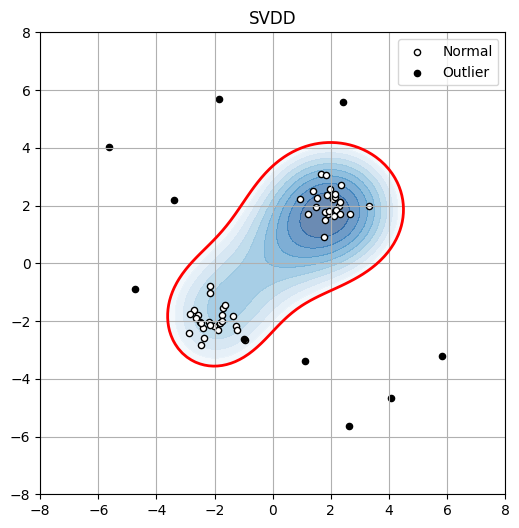

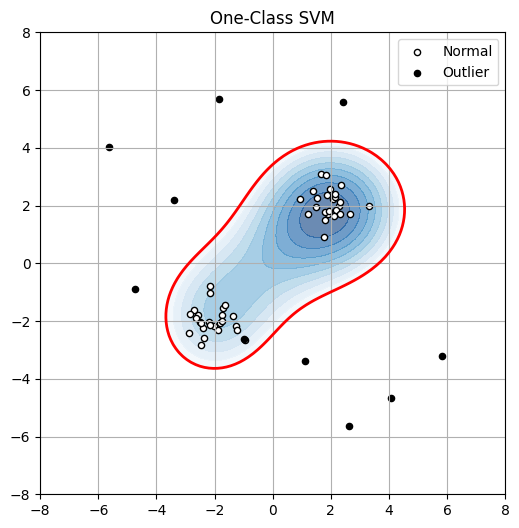

In [13]:
# Visualization
xx, yy = np.meshgrid(np.linspace(-7.5, 7.5, 100),
                     np.linspace(-7.5, 7.5, 100))
grid_points = np.c_[xx.ravel(), yy.ravel()]

# SVDD decision function
Z_svdd = []
for pt in grid_points:
    val = decision_function_svdd(pt, alpha_svdd, X_normal, K_svdd, R_svdd, gamma=0.1)
    Z_svdd.append(val)
Z_svdd = np.array(Z_svdd).reshape(xx.shape)

# One-Class SVM decision function
Z_oc = []
for pt in grid_points:
    val = decision_function_oneclass(pt, alpha_oc, X_normal, K_oc, rho_oc, gamma=0.1)
    Z_oc.append(val)
Z_oc = np.array(Z_oc).reshape(xx.shape)

# Plot results for SVDD
plt.figure(figsize=(6,6))
plt.contourf(xx, yy, Z_svdd, levels=np.linspace(Z_svdd.min(), 0, 10),
             cmap=plt.cm.Blues_r, alpha=0.6)
plt.contour(xx, yy, Z_svdd, levels=[0], linewidths=2, colors='red')
plt.scatter(X_normal[:,0], X_normal[:,1], c='white', s=20, edgecolors='k', label='Normal')
plt.scatter(X_outliers[:,0], X_outliers[:,1], c='black', s=20, edgecolors='k', label='Outlier')
plt.title("SVDD")
plt.xlim([-8,8])
plt.ylim([-8,8])
plt.legend()
plt.grid(True)
plt.show()

# Plot results for One-Class SVM
plt.figure(figsize=(6,6))
plt.contourf(xx, yy, Z_oc, levels=np.linspace(Z_oc.min(), 0, 10),
             cmap=plt.cm.Blues_r, alpha=0.6)
plt.contour(xx, yy, Z_oc, levels=[0], linewidths=2, colors='red')
plt.scatter(X_normal[:,0], X_normal[:,1], c='white', s=20, edgecolors='k', label='Normal')
plt.scatter(X_outliers[:,0], X_outliers[:,1], c='black', s=20, edgecolors='k', label='Outlier')
plt.title("One-Class SVM")
plt.xlim([-8,8])
plt.ylim([-8,8])
plt.legend()
plt.grid(True)
plt.show()